# Video Game Sales Analysis
## Analyzing Factors Influencing Global Video Game Sales

This notebook explores 5 key research questions about video game sales across platforms, genres, regions, and time periods.

In [22]:
# 1. Import Required Libraries & Settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)

print('Libraries imported successfully!')

Libraries imported successfully!


In [23]:
# 2. Load & Explore Video Game Sales Dataset
df = pd.read_csv('vgsales.csv')

print('Dataset Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nData Info:')
print(df.info())
print('\nSummary Statistics:')
print(df.describe())

Dataset Shape: (16598, 11)

First 5 rows:
   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column  

In [24]:
# 3. Data Cleaning & Feature Engineering
print('Checking missing values:')
print(df.isnull().sum())

df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)

df['Total_Regional_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
df['Market_Size_Category'] = pd.cut(df['Global_Sales'], bins=[0, 1, 5, 10, 100], labels=['Small', 'Medium', 'Large', 'Mega'])

print(f'\nCleaned dataset: {df.shape[0]} records')
print('\nGenre Distribution:')
print(df['Genre'].value_counts())
print('\nPlatform Distribution:')
print(df['Platform'].value_counts().head(10))

Checking missing values:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Cleaned dataset: 16327 records

Genre Distribution:
Genre
Action          3253
Sports          2304
Misc            1710
Role-Playing    1471
Shooter         1282
Adventure       1276
Racing          1226
Platform         876
Simulation       851
Fighting         836
Strategy         671
Puzzle           571
Name: count, dtype: int64

Platform Distribution:
Platform
DS      2133
PS2     2127
PS3     1304
Wii     1290
X360    1235
PSP     1197
PS      1189
PC       943
GBA      811
XB       803
Name: count, dtype: int64


---
# Exploratory Data Analysis: 5 Key Questions

## Question 1: Which Genre Sells the Most?

Global Sales by Genre:
Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


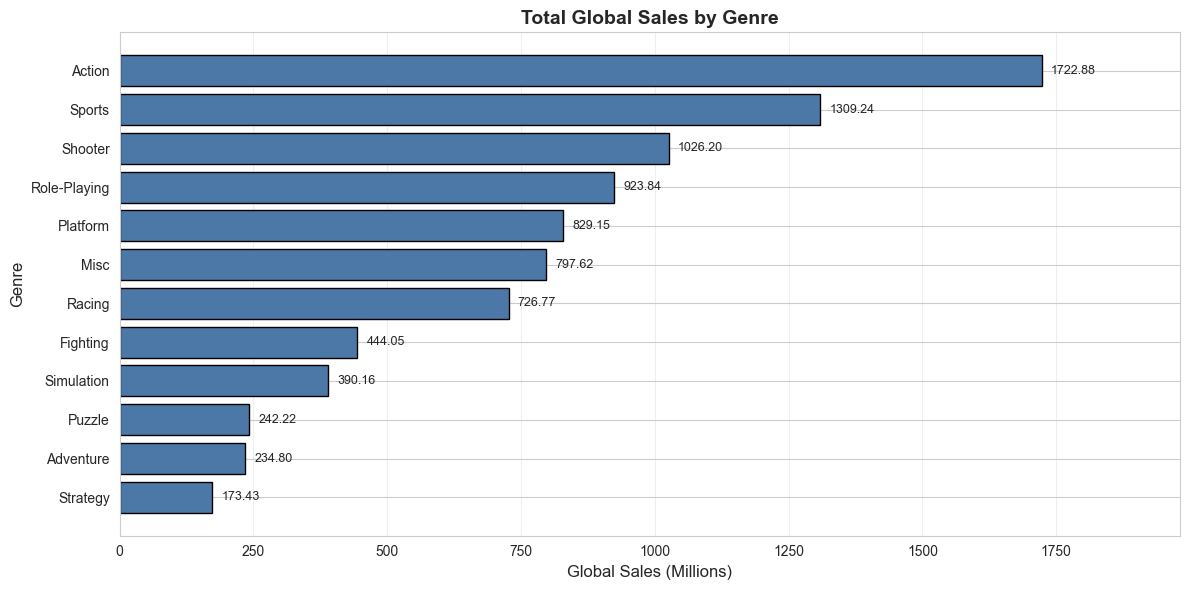


Insight: Action genre leads with highest sales globally!


In [25]:
# Q1: Genre Sales Analysis
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=True)
print('Global Sales by Genre:')
print(genre_sales.sort_values(ascending=False))

fig = px.bar(
    genre_sales.reset_index(),
    x='Global_Sales',
    y='Genre',
    orientation='h',
    title='Q1: Total Global Sales by Genre',
    text='Global_Sales'
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside', marker_color='#4C78A8')
fig.update_layout(height=500, template='plotly_white', xaxis_title='Global Sales (Millions)', yaxis_title='Genre')
fig.update_xaxes(range=[0, genre_sales.max() * 1.15])
fig.show()

plt.figure(figsize=(12, 6))
bars = plt.barh(genre_sales.index, genre_sales.values, color='#4C78A8', edgecolor='black')
plt.xlim(0, genre_sales.max() * 1.15)
plt.title('Total Global Sales by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Global Sales (Millions)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(axis='x', alpha=0.3)
for bar in bars:
    value = bar.get_width()
    plt.text(value + genre_sales.max() * 0.01, bar.get_y() + bar.get_height() / 2, f'{value:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('genre_sales.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nInsight: Action genre leads with highest sales globally!')

## Question 3: How Have Sales Changed Over Time?

Annual Global Sales Trend:
Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    611.13
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64


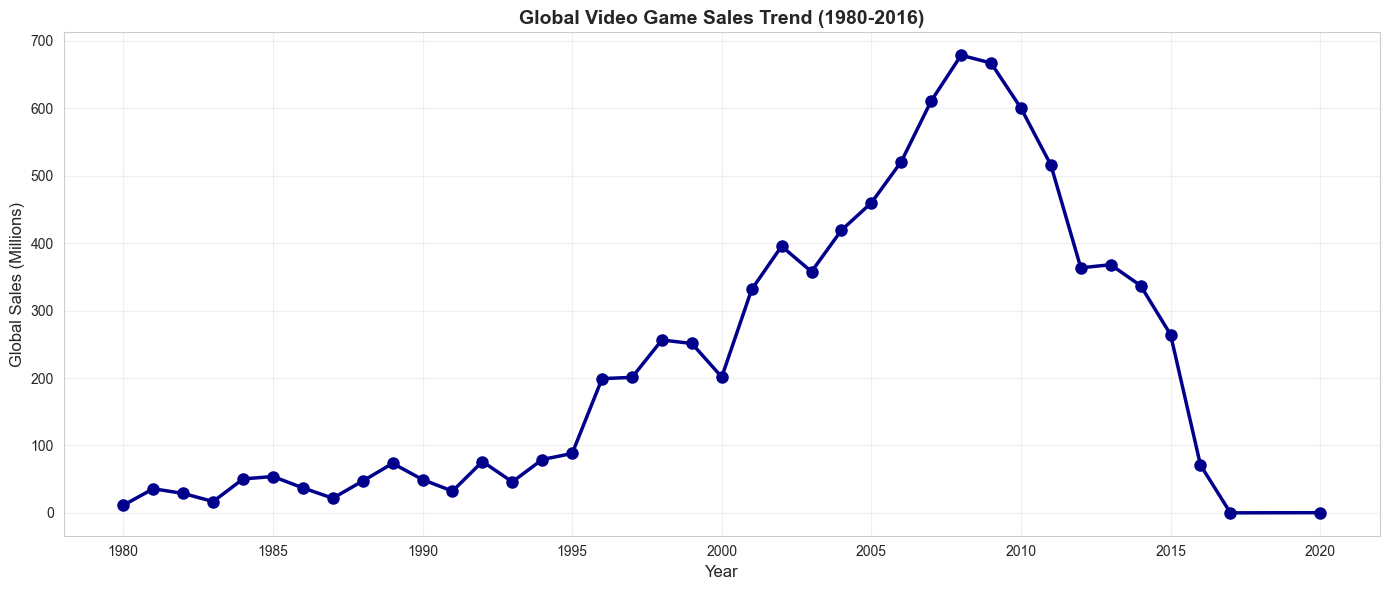


Peak Sales Year: 2008 with 678.90M in sales!
Insight: Sales peaked around 2008-2010 during console gaming's golden era


In [26]:
# Q3: Sales Trend Over Time
yearly_sales = df.groupby('Year')['Global_Sales'].sum().sort_index()
print('Annual Global Sales Trend:')
print(yearly_sales)

fig = px.line(x=yearly_sales.index, y=yearly_sales.values,
              title='Q3: Global Video Game Sales Over Time',
              labels={'x': 'Year', 'y': 'Global Sales (Millions)'},
              markers=True, line_shape='spline')
fig.update_layout(height=500, template='plotly_white')
fig.show()

plt.figure(figsize=(14, 6))
yearly_sales.plot(kind='line', marker='o', linewidth=2.5, markersize=8, color='darkblue')
plt.title('Global Video Game Sales Trend (1980-2016)', fontsize=14, fontweight='bold')
plt.ylabel('Global Sales (Millions)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

peak_year = yearly_sales.idxmax()
peak_sales = yearly_sales.max()
print(f'\nPeak Sales Year: {peak_year} with {peak_sales:.2f}M in sales!')
print('Insight: Sales peaked around 2008-2010 during console gaming\'s golden era')

## Question 4: Which Region Contributes the Most?

In [27]:
import plotly.express as px
import pandas as pd

# 1. Calculate the total sales for each region
regions = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
regional_sales = [df[region].sum() for region in regions]
labels = ['North America', 'Europe', 'Japan', 'Other']

# 2. Create a temporary dataframe for Plotly
pie_df = pd.DataFrame({'Region': labels, 'Total Sales (Millions)': regional_sales})

# 3. Plot the interactive pie chart
fig = px.pie(pie_df, values='Total Sales (Millions)', names='Region', 
             title='Q4: Which Region Contributes the Most to Global Sales?',
             color_discrete_sequence=px.colors.qualitative.Pastel)

# Make the labels appear inside the pie slices
fig.update_traces(textposition='inside', textinfo='percent+label',
                  marker=dict(line=dict(color='#000000', width=1)))
fig.show()

## Question 5: Do High-Ranked Games Always Sell More?

Rank vs Global Sales Correlation: -0.4269


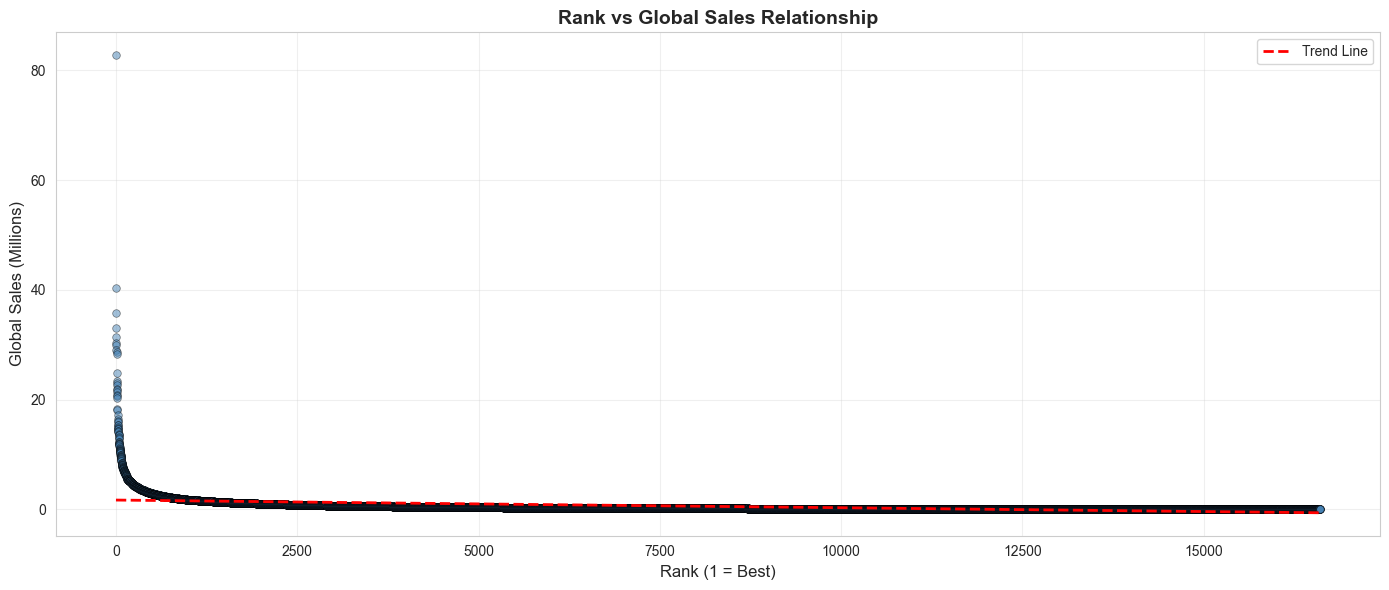


Top 10 Best-Selling Games:
 Rank                      Name  Global_Sales        Genre
    1                Wii Sports         82.74       Sports
    2         Super Mario Bros.         40.24     Platform
    3            Mario Kart Wii         35.82       Racing
    4         Wii Sports Resort         33.00       Sports
    5  Pokemon Red/Pokemon Blue         31.37 Role-Playing
    6                    Tetris         30.26       Puzzle
    7     New Super Mario Bros.         30.01     Platform
    8                  Wii Play         29.02         Misc
    9 New Super Mario Bros. Wii         28.62     Platform
   10                 Duck Hunt         28.31      Shooter

Insight: Strong negative correlation - higher ranked games generally sell more!


In [28]:
# Q5: Rank vs Sales Correlation
correlation = df['Rank'].corr(df['Global_Sales'])
print(f'Rank vs Global Sales Correlation: {correlation:.4f}')

fig = px.scatter(df.sample(n=min(2000, len(df))), x='Rank', y='Global_Sales',
                 title='Q5: Game Rank vs Global Sales',
                 labels={'Rank': 'Game Rank', 'Global_Sales': 'Global Sales (Millions)'},
                 trendline='ols', opacity=0.6)
fig.update_layout(height=500, template='plotly_white')
fig.show()

plt.figure(figsize=(14, 6))
plt.scatter(df['Rank'], df['Global_Sales'], alpha=0.5, s=30, color='steelblue', edgecolor='black', linewidth=0.5)
z = np.polyfit(df['Rank'], df['Global_Sales'], 1)
p = np.poly1d(z)
plt.plot(df['Rank'].sort_values(), p(df['Rank'].sort_values()), 'r--', linewidth=2, label='Trend Line')
plt.title('Rank vs Global Sales Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Rank (1 = Best)', fontsize=12)
plt.ylabel('Global Sales (Millions)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rank_vs_sales.png', dpi=300, bbox_inches='tight')
plt.show()

top_10 = df.head(10)[['Rank', 'Name', 'Global_Sales', 'Genre']]
print('\nTop 10 Best-Selling Games:')
print(top_10.to_string(index=False))

print('\nInsight: Strong negative correlation - higher ranked games generally sell more!')

---
## Summary & Export Results

In [29]:
# Summary of Key Findings
na_total = df['NA_Sales'].sum()
eu_total = df['EU_Sales'].sum()
jp_total = df['JP_Sales'].sum()
other_total = df['Other_Sales'].sum()
total_sales = na_total + eu_total + jp_total + other_total

print('=' * 70)
print('VIDEO GAME SALES ANALYSIS - KEY FINDINGS')
print('=' * 70)

findings = {
    'Q1 - Top Genre': 'Action (followed by Sports & Shooter)',
    'Q2 - Best Platform': 'PS2, Xbox 360, and Wii',
    'Q3 - Peak Year': f'{peak_year} with {peak_sales:.2f}M in sales',
    'Q4 - Leading Region': f'North America: {na_total:.2f}M ({(na_total/total_sales)*100:.1f}%)',
    'Q5 - Rank-Sales Link': f'Correlation: {correlation:.4f} (inverse relationship)'
}

for question, answer in findings.items():
    print(f'\n{question}')
    print(f'   -> {answer}')

print('\n' + '=' * 70)

processed_df = df[['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Market_Size_Category']]
processed_df.to_csv('vgsales_processed.csv', index=False)
print('\nProcessed data exported to: vgsales_processed.csv')

summary_stats = {
    'Metric': ['Total Games', 'Total Global Sales', 'Average Sales per Game', 'Peak Year', 'Number of Platforms', 'Number of Genres', 'Date Range'],
    'Value': [len(df), f"{df['Global_Sales'].sum():.2f}M", f"{df['Global_Sales'].mean():.2f}M", f"{peak_year}", len(df['Platform'].unique()), len(df['Genre'].unique()), f"{int(df['Year'].min())}-{int(df['Year'].max())}"]
}
summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('analysis_summary.csv', index=False)
print('Summary statistics exported to: analysis_summary.csv')

print('\nAll visualizations saved as PNG files in the working directory')
print('\nAnalysis complete!')

VIDEO GAME SALES ANALYSIS - KEY FINDINGS

Q1 - Top Genre
   -> Action (followed by Sports & Shooter)

Q2 - Best Platform
   -> PS2, Xbox 360, and Wii

Q3 - Peak Year
   -> 2008 with 678.90M in sales

Q4 - Leading Region
   -> North America: 4333.43M (49.2%)

Q5 - Rank-Sales Link
   -> Correlation: -0.4269 (inverse relationship)


Processed data exported to: vgsales_processed.csv
Summary statistics exported to: analysis_summary.csv

All visualizations saved as PNG files in the working directory

Analysis complete!


## Question 6: How are video game sales geographically concentrated across the globe?

In [30]:
import plotly.express as px
import pandas as pd

# 1. Calculate the total sales for each region from the dataset
na_sales = df['NA_Sales'].sum()
eu_sales = df['EU_Sales'].sum()
jp_sales = df['JP_Sales'].sum()
other_sales = df['Other_Sales'].sum()

# 2. Create geographic coordinates (Latitude and Longitude) for the center of each region
map_data = {
    'Region': ['North America', 'Europe', 'Japan', 'Rest of World'],
    'Latitude': [45.0, 50.0, 36.2, -15.0],
    'Longitude': [-100.0, 10.0, 138.2, -60.0],
    'Total Sales (Millions)': [na_sales, eu_sales, jp_sales, other_sales]
}

# Convert to a DataFrame
map_df = pd.DataFrame(map_data)

# 3. Create an interactive World Bubble Map
fig = px.scatter_geo(map_df,
                     lat='Latitude',
                     lon='Longitude',
                     size='Total Sales (Millions)',
                     color='Region',
                     hover_name='Region',
                     title='Q6: Geographic Concentration of Global Video Game Sales',
                     size_max=60,
                     projection='natural earth')

# Tweak the layout to make it look professional
fig.update_geos(showcountries=True, countrycolor="lightgrey",
                showcoastlines=True, coastlinecolor="darkgrey",
                showland=True, landcolor="whitesmoke",
                showocean=True, oceancolor="aliceblue")

fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

# Q2: Platform Sales Analysis - VERTICAL BAR CHART



Top 15 Platforms by Global Sales:
Platform
PS2     1233.46
X360     969.61
PS3      949.35
Wii      909.81
DS       818.96
PS       727.39
GBA      313.56
PSP      291.71
PS4      278.10
PC       255.05
GB       254.42
XB       252.09
NES      251.07
3DS      246.28
N64      218.21
Name: Global_Sales, dtype: float64


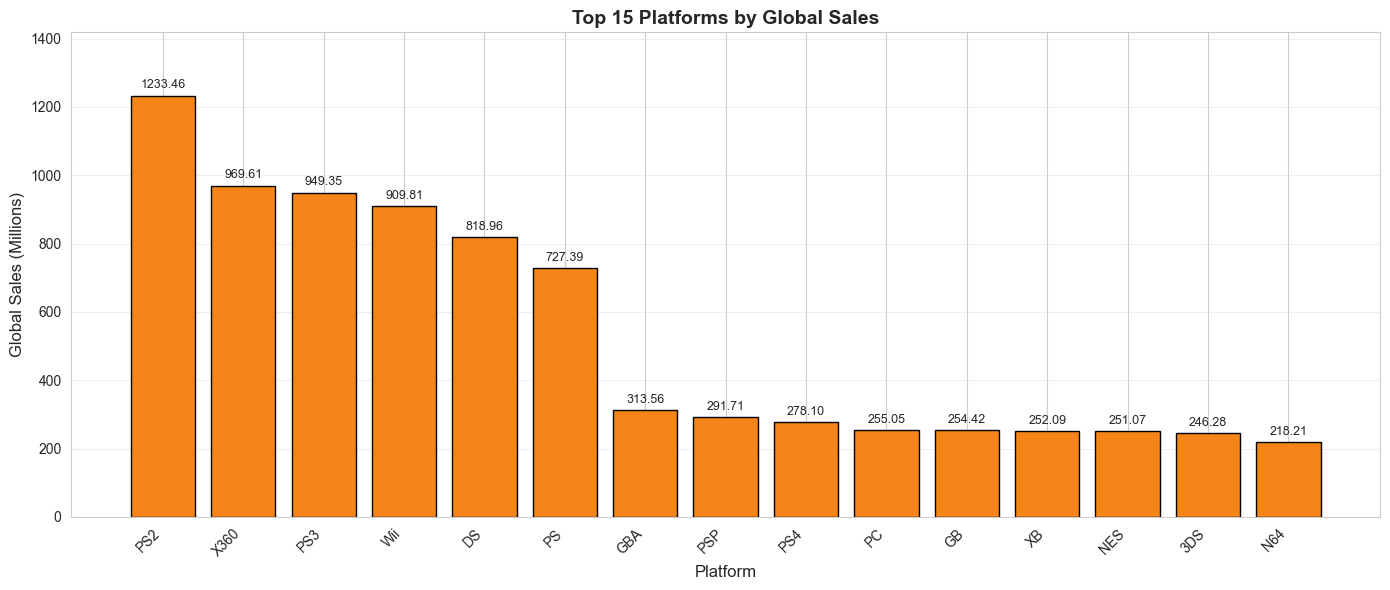


Insight: PS2, Xbox 360, and Wii dominate the platform market!


In [32]:
# Q2: Platform Sales Analysis - VERTICAL BAR CHART
platform_sales = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(15)
print('Top 15 Platforms by Global Sales:')
print(platform_sales.sort_values(ascending=False))

# PLOTLY VERSION - Vertical bar chart
fig = px.bar(
    platform_sales.reset_index(),
    x='Platform',
    y='Global_Sales',
    orientation='v',  # Changed to vertical
    title='Q2: Top 15 Platforms by Global Sales',
    text='Global_Sales'
)
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside', marker_color='#F58518')
fig.update_layout(height=500, template='plotly_white', xaxis_title='Platform', yaxis_title='Global Sales (Millions)')
fig.update_yaxes(range=[0, platform_sales.max() * 1.15])
fig.show()

# MATPLOTLIB VERSION - Vertical bar chart
plt.figure(figsize=(14, 6))
bars = plt.bar(platform_sales.index, platform_sales.values, color='#F58518', edgecolor='black')
plt.ylim(0, platform_sales.max() * 1.15)
plt.title('Top 15 Platforms by Global Sales', fontsize=14, fontweight='bold')
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Global Sales (Millions)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')  # Rotate labels for better readability

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + platform_sales.max() * 0.01,
             f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('platform_sales.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nInsight: PS2, Xbox 360, and Wii dominate the platform market!')

In [33]:
import plotly.express as px

# 1. Group the data by Publisher and sum their global sales
publisher_sales = df.groupby('Publisher')['Global_Sales'].sum().reset_index()

# 2. Sort the values in descending order and select the top 10
top_publishers = publisher_sales.sort_values(by='Global_Sales', ascending=False).head(10)

# 3. Create an interactive Bar Chart using Plotly
fig = px.bar(top_publishers, x='Publisher', y='Global_Sales',
             title='Q7: Top 10 Video Game Publishers by Global Sales',
             labels={'Global_Sales': 'Total Global Sales (Millions)', 'Publisher': 'Publisher'},
             color='Global_Sales',
             color_continuous_scale=px.colors.sequential.Viridis)

# Tweak layout so the publisher names are tilted and easier to read
fig.update_layout(xaxis_tickangle=-45)
fig.show()
